# Solver UN a 3 equazioni con metodo spettrale Sciantix

Questo notebook risolve il sistema per il gas in soluzione `c`, il gas in bolle bulk `m_b` e il gas in bolle su dislocazioni `m_d` usando lo schema del solver Sciantix `SpectralDiffusion3equationsExchange` descritto in `UNcode.md`.

Le correlazioni fisiche sono quelle riportate in `UNmodel.md`, con una nota: per riprodurre il codice Sciantix il denominatore del sink da dislocazioni usa `-3/5`, come in `src/classes/System.C`, non `-5/3`.

Il codice sotto usa solo la libreria standard Python. `matplotlib` è opzionale: se non è installato, il solver gira comunque e stampa i risultati.

Rates used by the Sciantix-style 3x3 solver
                D1 = 4.293480e-19
                D2 = 0.000000e+00
                D3 = 1.850000e-19
                Dg = 6.143480e-19
              beta = 2.400000e+19
               g_b = 9.341351e-05
               g_d = 3.346932e-05
               b_b = 2.406349e-05
               b_d = 2.406349e-05
               den = 3.486670e+00
  free_dislocation = 2.992800e+13

Final concentrations
c   = 4.379531e+23 at/m3
m_b = 1.123760e+24 at/m3
m_d = 4.026343e+23 at/m3
sum = 1.964347e+24 at/m3


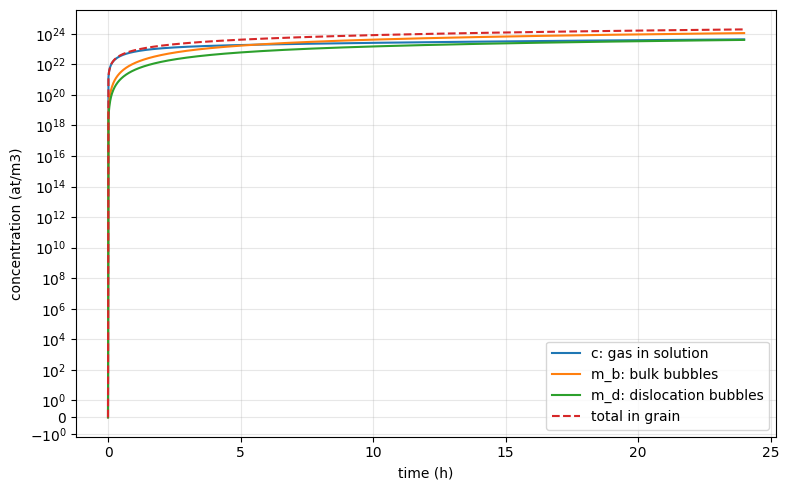

In [1]:
import math
from dataclasses import dataclass

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None


@dataclass
class UNParameters:
    # Operating conditions
    temperature: float = 1600.0              # K
    fission_rate: float = 1.0e20             # fiss / (m3 s)
    grain_radius: float = 5.0e-6             # m
    final_time: float = 24.0 * 3600.0        # s
    dt: float = 60.0                         # s
    n_modes: int = 40                        # Sciantix default

    # Gas production: beta = yield * fission_rate
    xe_yield: float = 0.24                   # atoms / fission, as in SetSystem.C for Xe in UN
    precursor_factor: float = 1.0            # Xe stable gas

    # Xe diffusivity in UN, Rizk / UNmodel.md
    D10: float = 1.56e-3                     # m2/s
    Q1: float = 4.94                         # eV
    A20: float = 1.21e-67                    # m(7/2) / s(1/2)
    B21: float = 25.87                       # eV
    B22: float = -1.49                       # eV2
    B23: float = 0.0                         # eV3
    A30: float = 1.85e-39                    # m5
    kB: float = 8.617333262e-5               # eV/K
    use_sciantix_D2_zero: bool = True        # Sciantix UN code sets D2 = 0 for Xe

    # Bubble / dislocation geometry
    radius_in_lattice: float = 0.21e-9       # m
    R_b: float = 1.0e-9                      # m, bulk bubble radius without lattice offset
    N_b: float = 1.0e22                      # bub/m3, example value
    R_d: float = 1.0e-9                      # m, dislocation bubble radius without lattice offset
    N_d: float = 3.6e19                      # bub/m3, from UNmodel.md
    rho_d: float = 3.0e13                    # 1/m2
    r_d: float = 3.46e-10                    # m
    Z_d: float = 5.0

    # Scaling factors, kept explicit to mirror Sciantix
    diffusivity_sf: float = 1.0
    trapping_sf: float = 1.0
    resolution_sf: float = 1.0

    # Initial volume-averaged gas concentrations
    c0: float = 0.0                          # at/m3
    mb0: float = 0.0                         # at/m3
    md0: float = 0.0                         # at/m3


def xe_diffusivity_UN(p):
    T = p.temperature
    F = p.fission_rate
    kBT = p.kB * T
    D1 = p.D10 * math.exp(-p.Q1 / kBT)
    if p.use_sciantix_D2_zero:
        D2 = 0.0
    else:
        D2 = p.A20 * math.sqrt(F) * math.exp(-p.B21 / kBT - p.B22 / kBT**2 - p.B23 / kBT**3)
    D3 = p.A30 * F
    Dg = (D1 + D2 + D3) * p.diffusivity_sf * p.precursor_factor
    return Dg, {"D1": D1, "D2": D2, "D3": D3, "Dg": Dg}


def b0_resolution(R):
    return 1.0e-25 * (2.64 - 2.02 * math.exp(-2.61e-9 / R))


def resolution_rates_UN(p):
    Rb_eff = p.R_b + p.radius_in_lattice
    Rd_eff = p.R_d + p.radius_in_lattice
    b_b = p.fission_rate * b0_resolution(Rb_eff) * p.resolution_sf
    b_d = p.fission_rate * b0_resolution(Rd_eff) * p.resolution_sf
    return b_b, b_d


def trapping_rates_UN(p, Dg):
    Rb_eff = p.R_b + p.radius_in_lattice
    Rd_eff = p.R_d + p.radius_in_lattice
    g_b = 0.0 if p.N_b == 0.0 else 4.0 * math.pi * Dg * Rb_eff * p.N_b

    Gamma_d = 1.0 / math.sqrt(math.pi * p.rho_d)
    den = math.log(Gamma_d / (p.Z_d * p.r_d)) - 3.0 / 5.0
    if den <= 0.0:
        raise ValueError(f"Invalid dislocation sink denominator: {den:g}")

    free_dislocation = max(p.rho_d - 2.0 * p.R_d * p.N_d, 0.0)
    term_bubbles = 4.0 * math.pi * Dg * Rd_eff * p.N_d
    term_dislocation = (2.0 * math.pi * Dg / den) * free_dislocation
    g_d = term_bubbles + term_dislocation

    return p.trapping_sf * g_b, p.trapping_sf * g_d, {
        "Gamma_d": Gamma_d,
        "den": den,
        "free_dislocation": free_dislocation,
        "term_bubbles": term_bubbles,
        "term_dislocation": term_dislocation,
    }


def beta_production(p):
    return p.xe_yield * p.fission_rate


def initialize_modes_from_average(average, n_modes, n_iter=20):
    # Same iterative projection pattern used by Sciantix initialization.
    modes = [0.0 for _ in range(n_modes)]
    projection_coeff = -math.sqrt(8.0 / math.pi)
    remainder = average
    for _ in range(n_iter):
        reconstructed = 0.0
        for i in range(n_modes):
            n = i + 1
            n_coeff = (-1.0) ** n / n
            modes[i] += projection_coeff * n_coeff * remainder
            reconstructed += projection_coeff * n_coeff * modes[i] * 3.0 / (4.0 * math.pi)
        remainder = average - reconstructed
    return modes


def reconstruct_average(modes):
    projection_coeff = -2.0 * math.sqrt(2.0 / math.pi)
    average = 0.0
    for i, value in enumerate(modes):
        n = i + 1
        n_coeff = (-1.0) ** n / n
        average += projection_coeff * n_coeff * value / ((4.0 / 3.0) * math.pi)
    return average


def det3(A):
    return (
        A[0][0] * (A[1][1] * A[2][2] - A[1][2] * A[2][1])
        - A[0][1] * (A[1][0] * A[2][2] - A[1][2] * A[2][0])
        + A[0][2] * (A[1][0] * A[2][1] - A[1][1] * A[2][0])
    )


def solve3x3_cramer(A, b):
    # Cramer's rule, equivalent to Sciantix Solver::Laplace3x3.
    detA = det3(A)
    if detA == 0.0:
        raise ZeroDivisionError("Singular 3x3 system in spectral mode solve")
    Ax = [[b[i], A[i][1], A[i][2]] for i in range(3)]
    Ay = [[A[i][0], b[i], A[i][2]] for i in range(3)]
    Az = [[A[i][0], A[i][1], b[i]] for i in range(3)]
    return [det3(Ax) / detA, det3(Ay) / detA, det3(Az) / detA]


def sciantix_3x3_exchange_step(modes_c, modes_mb, modes_md, Dg, R, beta, g_b, g_d, b_b, b_d, dt):
    projection_coeff = -2.0 * math.sqrt(2.0 / math.pi)
    diffusion_rate_coeff = math.pi**2 * Dg / R**2

    for i in range(len(modes_c)):
        n = i + 1
        n_coeff = (-1.0) ** n / n
        diffusion_rate = diffusion_rate_coeff * n**2
        source_rate = projection_coeff * beta * n_coeff

        A = [
            [1.0 + (diffusion_rate + g_b + g_d) * dt, -b_b * dt, -b_d * dt],
            [-g_b * dt, 1.0 + b_b * dt, 0.0],
            [-g_d * dt, 0.0, 1.0 + b_d * dt],
        ]
        rhs = [modes_c[i] + source_rate * dt, modes_mb[i], modes_md[i]]
        modes_c[i], modes_mb[i], modes_md[i] = solve3x3_cramer(A, rhs)

    return reconstruct_average(modes_c), reconstruct_average(modes_mb), reconstruct_average(modes_md)


def solve_UN_sciantix(p):
    Dg, D_parts = xe_diffusivity_UN(p)
    b_b, b_d = resolution_rates_UN(p)
    g_b, g_d, trapping_parts = trapping_rates_UN(p, Dg)
    beta = beta_production(p)

    modes_c = initialize_modes_from_average(p.c0, p.n_modes)
    modes_mb = initialize_modes_from_average(p.mb0, p.n_modes)
    modes_md = initialize_modes_from_average(p.md0, p.n_modes)

    n_steps = int(math.ceil(p.final_time / p.dt))
    times = [0.0]
    c = [reconstruct_average(modes_c)]
    mb = [reconstruct_average(modes_mb)]
    md = [reconstruct_average(modes_md)]

    for _ in range(n_steps):
        dt = min(p.dt, p.final_time - times[-1])
        if dt <= 0.0:
            break
        c_new, mb_new, md_new = sciantix_3x3_exchange_step(
            modes_c, modes_mb, modes_md, Dg, p.grain_radius, beta, g_b, g_d, b_b, b_d, dt
        )
        times.append(times[-1] + dt)
        c.append(c_new)
        mb.append(mb_new)
        md.append(md_new)

    rates = {
        "Dg": Dg,
        "beta": beta,
        "g_b": g_b,
        "g_d": g_d,
        "b_b": b_b,
        "b_d": b_d,
        **D_parts,
        **trapping_parts,
    }
    return times, c, mb, md, rates


# Example run. Change these values to match a specific Sciantix case.
p = UNParameters(
    temperature=1600.0,
    fission_rate=1.0e20,
    grain_radius=5.0e-6,
    final_time=24.0 * 3600.0,
    dt=60.0,
    R_b=1.0e-9,
    N_b=1.0e22,
    R_d=1.0e-9,
    N_d=3.6e19,
    c0=0.0,
    mb0=0.0,
    md0=0.0,
)

times, c, mb, md, rates = solve_UN_sciantix(p)

print("Rates used by the Sciantix-style 3x3 solver")
for key in ["D1", "D2", "D3", "Dg", "beta", "g_b", "g_d", "b_b", "b_d", "den", "free_dislocation"]:
    print(f"{key:>18s} = {rates[key]:.6e}")

print("\nFinal concentrations")
print(f"c   = {c[-1]:.6e} at/m3")
print(f"m_b = {mb[-1]:.6e} at/m3")
print(f"m_d = {md[-1]:.6e} at/m3")
print(f"sum = {(c[-1] + mb[-1] + md[-1]):.6e} at/m3")

if plt is not None:
    hours = [t / 3600.0 for t in times]
    total = [ci + mbi + mdi for ci, mbi, mdi in zip(c, mb, md)]
    plt.figure(figsize=(8, 5))
    plt.plot(hours, c, label="c: gas in solution")
    plt.plot(hours, mb, label="m_b: bulk bubbles")
    plt.plot(hours, md, label="m_d: dislocation bubbles")
    plt.plot(hours, total, "--", label="total in grain")
    plt.xlabel("time (h)")
    plt.ylabel("concentration (at/m3)")
    plt.yscale("symlog", linthresh=1.0)
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("\nmatplotlib is not installed in this environment: skipping plot.")


## Strategia numerica per l’estensione del modello intragranulare UN

L’estensione del modello UN aggiunge alle tre variabili già risolte dal solver spettrale:

$$
c,\ m_b,\ m_d
$$

le variabili microstrutturali intragranulari:

$$
N_b,\ N_d,\ V_b,\ V_d,\ n_b,\ n_d
$$

dove:
- $N_b$ = concentrazione numerica delle bolle bulk;
- $N_d$ = concentrazione numerica delle bolle su dislocazioni;
- $V_b$ = volume medio delle bolle bulk;
- $V_d$ = volume medio delle bolle su dislocazioni;
- $n_b$ = concentrazione volumetrica di vacanze associate alle bolle bulk;
- $n_d$ = concentrazione volumetrica di vacanze associate alle bolle su dislocazioni.

La scelta numerica più coerente con l’approccio SCIANTIX è non trasformare tutto il modello in un unico grande sistema accoppiato, ma usare un approccio di **operator splitting**.

In pratica, si mantiene il solver spettrale a 3 equazioni per:

$$
c,\ m_b,\ m_d
$$

e poi si aggiornano in sequenza le variabili microstrutturali:

$$
N_b
\rightarrow
n_b,\ n_d
\rightarrow
V_b,\ V_d
\rightarrow
N_d
\rightarrow
R_b,\ R_d
$$

La sequenza logica è quindi:

1. risolvere la distribuzione del gas con il solver spettrale 3×3;
2. aggiornare la concentrazione numerica delle bolle bulk $N_b$;
3. aggiornare le concentrazioni volumetriche di vacanze $n_b$ e $n_d$;
4. aggiornare i volumi medi delle bolle $V_b$ e $V_d$;
5. aggiornare $N_d$ tramite il termine di coalescenza tra bolle su dislocazioni;
6. aggiornare i raggi $R_b$ e $R_d$ dai volumi medi.

Questa scelta segue la logica SCIANTIX-style: coefficienti valutati all’inizio del passo temporale, soluzione implicita o semi-implicita delle equazioni principali, e aggiornamento sequenziale delle variabili di stato.

Il modello intragranulare può quindi essere esteso senza toccare subito il modello intergranulare. Il gas che lascia il grano viene calcolato come flusso verso il grain face, ma la crescita delle grain-face bubbles e il fission gas release possono essere implementati in un secondo momento come modulo separato.

## Nota sulla nucleazione e conservazione degli atomi

Nel modello Rizk (2025), il termine di nucleazione delle bolle bulk compare nella sola equazione per la concentrazione numerica delle bolle:

$$
\frac{\partial N_b}{\partial t}
=
\nu_b
-
b_b\phi_bN_b
$$

ma non compare esplicitamente come termine di sottrazione nella equazione del gas in soluzione:

$$
\frac{\partial c}{\partial t}
=
D_g\nabla^2 c
-
(g_b+g_d)c
+
b_bm_b
+
b_dm_d
+
\beta
$$

né come termine di aggiunta nella equazione del gas nelle bolle bulk:

$$
\frac{\partial m_b}{\partial t}
=
g_bc
-
b_bm_b
$$

Quindi, seguendo Rizk alla lettera, la nucleazione modifica il numero di bolle bulk $N_b$, ma il trasferimento di gas da $c$ a $m_b$ avviene tramite il trapping $g_bc$.

In Barani et al. per U$_3$Si$_2$, invece, la nucleazione omogenea è trattata come formazione di dimeri. In quel caso la nucleazione sottrae due atomi dalla soluzione e li aggiunge alla fase bolla:

$$
\frac{\partial c}{\partial t}
=
D\nabla^2 c
-
gc
+
bm
+
\beta
-
2\nu
$$

$$
\frac{\partial m}{\partial t}
=
gc
-
bm
+
2\nu
$$

La forma con $-2\nu$ e $+2\nu$ è più esplicitamente conservativa per gli atomi di gas, perché ogni evento di nucleazione consuma due atomi singoli e forma un dimero.

Nel codice UN attuale, se l’obiettivo è riprodurre Rizk/SIFGRS, si mantiene la forma Rizk:

$$
\frac{\partial c}{\partial t}
=
D_g\nabla^2 c
-
(g_b+g_d)c
+
b_bm_b
+
b_dm_d
+
\beta
$$

$$
\frac{\partial m_b}{\partial t}
=
g_bc
-
b_bm_b
$$

$$
\frac{\partial N_b}{\partial t}
=
\nu_b
-
b_b\phi_bN_b
$$

Se invece si vuole una variante più conservativa, ispirata a Barani U$_3$Si$_2$, si può usare:

$$
\frac{\partial c}{\partial t}
=
D_g\nabla^2 c
-
(g_b+g_d)c
+
b_bm_b
+
b_dm_d
+
\beta
-
2\nu_b
$$

$$
\frac{\partial m_b}{\partial t}
=
g_bc
-
b_bm_b
+
2\nu_b
$$

$$
\frac{\partial N_b}{\partial t}
=
\nu_b
-
b_b\phi_bN_b
$$

Per coerenza con Rizk, nel modello UN implementato qui si usa la prima scelta, cioè $\nu_b$ entra solo nella evoluzione di $N_b$.

## Equazioni risolte nel modello intragranulare esteso

Il codice risolve prima il sistema spettrale a 3 equazioni per:

$$
c,\ m_b,\ m_d
$$

e poi aggiorna in sequenza le variabili microstrutturali:

$$
N_b,\ N_d,\ V_b,\ V_d,\ n_b,\ n_d,\ R_b,\ R_d
$$

---

### 1. Gas in soluzione e gas intrappolato nelle bolle

$$
\frac{\partial c}{\partial t}
=
D_g\nabla^2 c
-
(g_b+g_d)c
+
b_bm_b
+
b_dm_d
+
\beta
$$

$$
\frac{\partial m_b}{\partial t}
=
g_bc
-
b_bm_b
$$

$$
\frac{\partial m_d}{\partial t}
=
g_dc
-
b_dm_d
$$

---

### 2. Concentrazione numerica delle bolle bulk

$$
\frac{\partial N_b}{\partial t}
=
\nu_b
-
b_b\phi_bN_b
$$

$$
\phi_b
=
\frac{1}{m_b'-1}
$$

$$
m_b'
=
\frac{m_b}{N_b}
$$

---

### 3. Concentrazione numerica delle bolle su dislocazioni

$$
\frac{\partial N_d}{\partial t}
=
\frac{N_d}{\rho_d}
\frac{\partial \rho_d}{\partial t}
-
4\lambda N_d^2
\frac{dV_d}{dt}
$$

Nel codice si assume:

$$
\frac{\partial \rho_d}{\partial t}
=
0
$$

quindi:

$$
\frac{\partial N_d}{\partial t}
=
-
4\lambda N_d^2
\frac{dV_d}{dt}
$$

---

### 4. Fattore di coalescenza

$$
\lambda
=
\frac{2-\xi}{2(1-\xi)^3}
$$

$$
\xi
=
V_dN_d
$$

$$
\xi
=
\frac{4}{3}\pi R_d^3N_d
$$

---

### 5. Assorbimento di vacanze

$$
\frac{\partial n_b}{\partial t}
=
\frac{2\pi D_v\delta_bN_b}
{k_BT\zeta_b}
\left(
p_b-p_b^{eq}
\right)
$$

$$
\frac{\partial n_d}{\partial t}
=
\frac{2\pi D_v\delta_dN_d}
{k_BT\zeta_d}
\left(
p_d-p_d^{eq}
\right)
$$

Nel codice:

$$
\frac{\partial n_i}{\partial t}
=
0
\qquad
\text{se}
\qquad
p_i \le p_i^{eq}
$$

$$
\frac{\partial n_i}{\partial t}
=
\frac{2\pi D_v\delta_iN_i}
{k_BT\zeta_i}
\left(
p_i-p_i^{eq}
\right)
\qquad
\text{se}
\qquad
p_i > p_i^{eq}
$$

con:

$$
i=b,d
$$

---

### 6. Pressione interna ed equilibrio meccanico

$$
p_i
=
\frac{k_BT m_i'}{n_i'\Omega}
$$

$$
p_i^{eq}
=
\frac{2\gamma}{R_i}
-
\sigma_h
$$

Nel codice, se:

$$
\sigma_h=0
$$

allora:

$$
p_i^{eq}
=
\frac{2\gamma}{R_i}
$$

---

### 7. Numero medio per bolla

$$
m_i'
=
\frac{m_i}{N_i}
$$

$$
n_i'
=
\frac{n_i}{N_i}
$$

con:

$$
i=b,d
$$

---

### 8. Volume medio delle bolle

$$
\frac{\partial V_b}{\partial t}
=
\frac{\Omega_{fg}}{N_b}
\frac{\partial m_b}{\partial t}
+
\frac{\Omega}{N_b}
\frac{\partial n_b}{\partial t}
$$

$$
\frac{\partial V_d}{\partial t}
=
\frac{\Omega_{fg}}{N_d}
\frac{\partial m_d}{\partial t}
+
\frac{\Omega}{N_d}
\frac{\partial n_d}{\partial t}
$$

Nel codice, dopo l’aggiornamento di \(N_i\), \(m_i\), \(n_i\), il volume viene anche ricostruito come:

$$
V_i
=
\frac{
\Omega_{fg}m_i+\Omega n_i
}{
N_i
}
$$

---

### 9. Raggio delle bolle

$$
R_b
=
\left(
\frac{3V_b}{4\pi}
\right)^{1/3}
$$

$$
R_d
=
\left(
\frac{3V_d}{4\pi}
\right)^{1/3}
$$

---

### 10. Gas uscito dal grano

Il gas prodotto cumulativo è:

$$
G(t)
=
\int_0^t \beta \, dt
$$

Il gas trattenuto nel grano è:

$$
G_{grain}
=
c+m_b+m_d
$$

Il gas arrivato al grain face è calcolato come bilancio:

$$
q_{gb}
=
G(t)
+
G(0)
-
G_{grain}
$$

Il rate verso il grain face è:

$$
\dot{q}_{gb}
=
\frac{dq_{gb}}{dt}
$$

Final intragranular state
           c = 3.192012e+23
          mb = 1.121284e+24
          md = 5.333619e+23
          Nb = 8.836514e+21
          Nd = 1.853745e+09
          Rb = 1.547599e-09
          Rd = 8.551006e-01
         nvb = 1.433800e+24
         nvd = 1.661844e+38
        q_gb = 9.975252e+22
     qdot_gb = 1.369474e+18
 swelling_ig = 4.855012e+09

Last-step rates
                D1 = 4.293480e-19
                D2 = 0.000000e+00
                D3 = 1.850000e-19
                Dg = 6.143480e-19
                Dv = 9.711886e-07
              beta = 2.400000e+19
               g_b = 1.198841e-04
               g_d = 3.322147e-05
               b_b = 2.182560e-05
               b_d = 6.200000e-06
              nu_b = 6.917084e+14
             phi_b = 7.943352e-03
          lambda_d = 5.000005e+17
     dVd_growth_dt = 3.346127e-19
  free_dislocation = 2.999683e+13


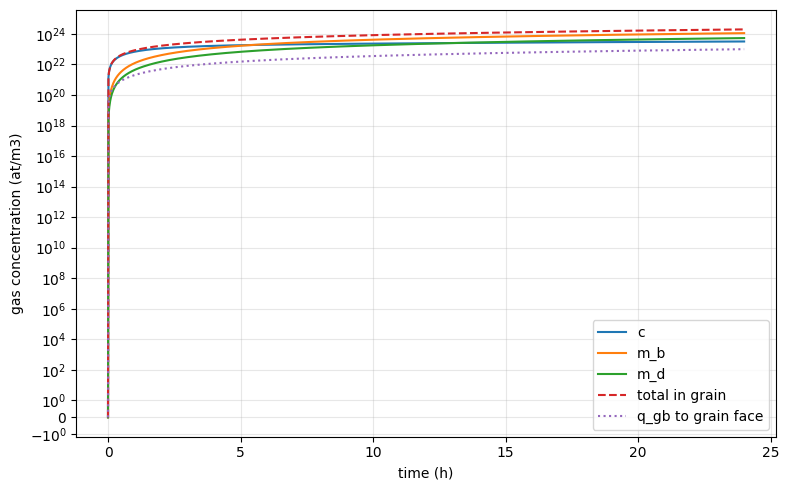

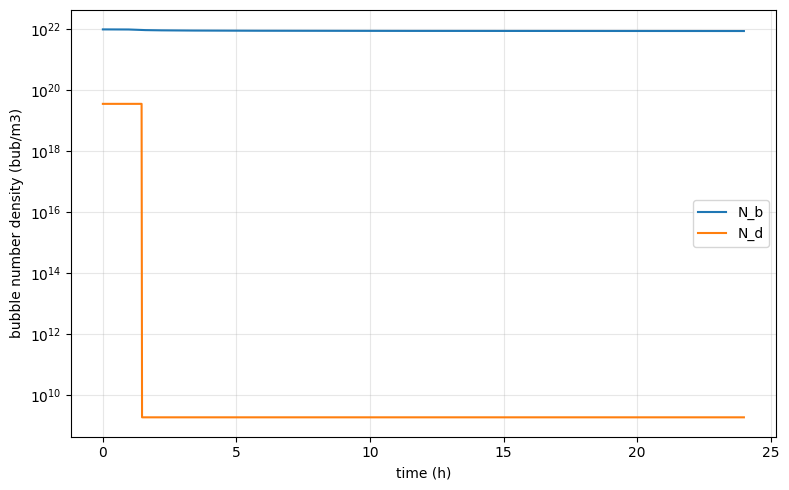

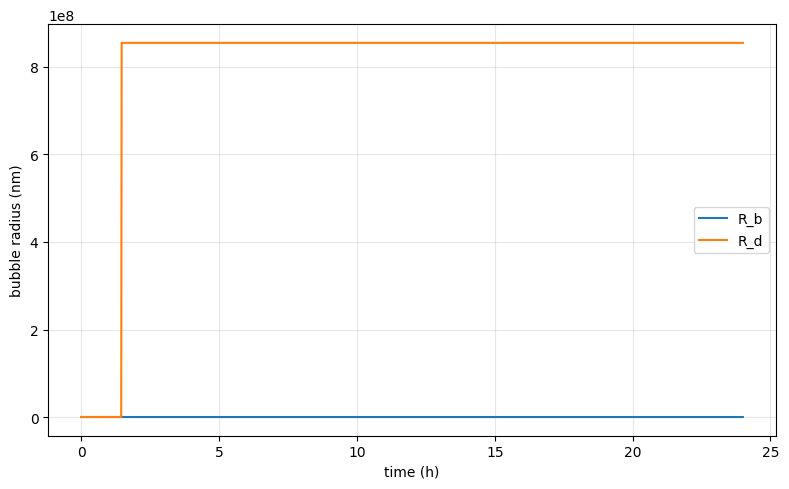

In [4]:
import math
from dataclasses import dataclass
from typing import Optional

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None


@dataclass
class UNParameters:
    # Operating conditions: stationary T and F
    temperature: float = 1600.0              # K
    fission_rate: float = 1.0e19             # fiss / (m3 s)
    grain_radius: float = 5.0e-6             # m
    final_time: float = 24.0 * 3600.0        # s
    dt: float = 60.0                         # s
    n_modes: int = 40                        # Sciantix default

    # Gas production
    xe_yield: float = 0.24                   # atoms / fission
    precursor_factor: float = 1.0            # stable Xe

    # Xe diffusivity in UN
    D10: float = 1.56e-3                     # m2/s
    Q1: float = 4.94                         # eV
    A20: float = 1.21e-67
    B21: float = 25.87
    B22: float = -1.49
    B23: float = 0.0
    A30: float = 1.85e-39                    # m5

    # Boltzmann constants
    kB_eV: float = 8.617333262e-5            # eV/K, for Arrhenius
    kB_J: float = 1.380649e-23               # J/K, for pressure/vacancy equations

    use_sciantix_D2_zero: bool = True

    # Vacancy diffusivity in UN
    D10_vU: float = 1.35e-2                  # m2/s
    Q1_vU: float = 5.66                      # eV
    A20_vU: float = 1.32e-19
    B21_vU: float = -0.62                    # eV
    B22_vU: float = -0.04                    # eV2

    # Bubble / material parameters
    radius_in_lattice: float = 0.21e-9       # m
    omega_fg: float = 8.5e-29                # m3/atom
    lattice_parameter: float = 4.889e-10     # m
    gamma_b: float = 1.11                    # J/m2
    hydrostatic_stress: float = 0.0          # Pa

    # Nucleation
    f_n: float = 1.0e-6

    # Dislocations
    rho_d: float = 3.0e13                    # m-2
    r_d: float = 3.46e-10                    # m
    Z_d: float = 5.0

    # Initial microstructure
    R_b: float = 1.0e-9                      # m
    N_b: float = 1.0e22                      # bub/m3
    R_d: float = 1.0e-9                      # m
    N_d: float = 3.6e19                      # bub/m3

    # Initial gas concentrations
    c0: float = 0.0                          # at/m3
    mb0: float = 0.0                         # at/m3
    md0: float = 0.0                         # at/m3

    # Initial vacancy concentrations in bubbles.
    # If None, they are initialized from initial R and N.
    nvb0: Optional[float] = None             # vac/m3
    nvd0: Optional[float] = None             # vac/m3

    # Scaling factors
    diffusivity_sf: float = 1.0
    trapping_sf: float = 1.0
    resolution_sf: float = 1.0

    # Numerical switches
    vacancy_absorption_only: bool = True
    update_bulk_vacancies: bool = True
    min_number_density: float = 1.0
    min_volume: float = 1.0e-36
    max_phi: float = 1.0


def omega_matrix(p):
    return p.lattice_parameter**3 / 4.0


def sphere_volume(R):
    return (4.0 / 3.0) * math.pi * max(R, 0.0)**3


def radius_from_volume(V):
    return (3.0 * max(V, 0.0) / (4.0 * math.pi)) ** (1.0 / 3.0)


def xe_diffusivity_UN(p):
    T = p.temperature
    F = p.fission_rate
    kBT = p.kB_eV * T

    D1 = p.D10 * math.exp(-p.Q1 / kBT)

    if p.use_sciantix_D2_zero:
        D2 = 0.0
    else:
        D2 = p.A20 * math.sqrt(F) * math.exp(
            -p.B21 / kBT
            - p.B22 / kBT**2
            - p.B23 / kBT**3
        )

    D3 = p.A30 * F
    Dg = (D1 + D2 + D3) * p.diffusivity_sf * p.precursor_factor

    return Dg, {"D1": D1, "D2": D2, "D3": D3, "Dg": Dg}


def vacancy_diffusivity_UN(p):
    T = p.temperature
    F = p.fission_rate
    kBT = p.kB_eV * T

    D1 = p.D10_vU * math.exp(-p.Q1_vU / kBT)

    D2 = math.sqrt(F) * p.A20_vU * math.exp(
        -p.B21_vU / kBT
        -p.B22_vU / kBT**2
    )

    Dv = D1 + D2

    return Dv, {"Dv1": D1, "Dv2": D2, "Dv": Dv}


def b0_resolution(R):
    R = max(R, 1.0e-15)
    return 1.0e-25 * (
        2.64
        - 2.02 * math.exp(-2.61e-9 / R)
    )


def resolution_rates_UN(p, R_b, R_d):
    Rb_eff = R_b + p.radius_in_lattice
    Rd_eff = R_d + p.radius_in_lattice

    b_b = p.fission_rate * b0_resolution(Rb_eff) * p.resolution_sf
    b_d = p.fission_rate * b0_resolution(Rd_eff) * p.resolution_sf

    return b_b, b_d


def trapping_rates_UN(p, Dg, R_b, N_b, R_d, N_d):
    Rb_eff = R_b + p.radius_in_lattice
    Rd_eff = R_d + p.radius_in_lattice

    if N_b <= 0.0:
        g_b = 0.0
    else:
        g_b = 4.0 * math.pi * Dg * Rb_eff * N_b

    Gamma_d = 1.0 / math.sqrt(math.pi * p.rho_d)

    den = math.log(Gamma_d / (p.Z_d * p.r_d)) - 3.0 / 5.0
    if den <= 0.0:
        raise ValueError(f"Invalid dislocation sink denominator: {den:g}")

    free_dislocation = max(p.rho_d - 2.0 * R_d * N_d, 0.0)

    term_bubbles = 4.0 * math.pi * Dg * Rd_eff * N_d
    term_dislocation = (2.0 * math.pi * Dg / den) * free_dislocation

    g_d = term_bubbles + term_dislocation

    return p.trapping_sf * g_b, p.trapping_sf * g_d, {
        "Gamma_d": Gamma_d,
        "den": den,
        "free_dislocation": free_dislocation,
        "term_bubbles": term_bubbles,
        "term_dislocation": term_dislocation,
    }


def beta_production(p):
    return p.xe_yield * p.fission_rate


def nucleation_rate_bulk(p, Dg, c):
    return (
        8.0
        * math.pi
        * p.f_n
        * Dg
        * p.omega_fg ** (1.0 / 3.0)
        * max(c, 0.0) ** 2
    )


def phi_bulk(mb, Nb, max_phi=1.0):
    if Nb <= 0.0:
        return 0.0

    atoms_per_bubble = mb / Nb

    if atoms_per_bubble <= 1.0:
        return 0.0

    return min(1.0 / (atoms_per_bubble - 1.0), max_phi)


def coalescence_lambda(Vd, Nd):
    xi = Vd * Nd
    xi = max(0.0, min(xi, 0.999999))

    return (2.0 - xi) / (2.0 * (1.0 - xi) ** 3)


def pressure_internal(p, m_gas, n_vac):
    if m_gas <= 0.0:
        return 0.0

    return (
        p.kB_J
        * p.temperature
        * m_gas
        / (max(n_vac, 1.0e-300) * omega_matrix(p))
    )


def pressure_equilibrium(p, R):
    return 2.0 * p.gamma_b / max(R, 1.0e-15) - p.hydrostatic_stress


def wigner_seitz_delta(N):
    return (3.0 / (4.0 * math.pi * max(N, 1.0))) ** (1.0 / 3.0)


def zeta_geometry(R, N):
    delta = wigner_seitz_delta(N)
    psi = max(R / delta, 1.0e-12)

    den = -psi**6 + 5.0 * psi**2 - 9.0 * psi + 5.0

    if den <= 1.0e-30:
        den = 1.0e-30

    return max(
        10.0 * psi * (1.0 + psi**3) / den,
        1.0e-30
    )


def vacancy_rate(p, Dv, R, N, m_gas, n_vac):
    if N <= 0.0:
        return 0.0

    p_int = pressure_internal(p, m_gas, n_vac)
    p_eq = pressure_equilibrium(p, R)

    driving = p_int - p_eq

    if p.vacancy_absorption_only and driving <= 0.0:
        return 0.0

    delta = wigner_seitz_delta(N)
    zeta = zeta_geometry(R, N)

    return (
        2.0
        * math.pi
        * Dv
        * delta
        * N
        / (p.kB_J * p.temperature * zeta)
        * driving
    )


def initialize_vacancy_concentration(p, N, R, m_gas):
    total_bubble_volume = N * sphere_volume(R)
    gas_volume = p.omega_fg * m_gas
    vacancy_volume = max(total_bubble_volume - gas_volume, 0.0)

    return vacancy_volume / omega_matrix(p)


def initialize_modes_from_average(average, n_modes, n_iter=20):
    modes = [0.0 for _ in range(n_modes)]

    projection_coeff = -math.sqrt(8.0 / math.pi)
    remainder = average

    for _ in range(n_iter):
        reconstructed = 0.0

        for i in range(n_modes):
            n = i + 1
            n_coeff = (-1.0) ** n / n

            modes[i] += projection_coeff * n_coeff * remainder

            reconstructed += (
                projection_coeff
                * n_coeff
                * modes[i]
                * 3.0
                / (4.0 * math.pi)
            )

        remainder = average - reconstructed

    return modes


def reconstruct_average(modes):
    projection_coeff = -2.0 * math.sqrt(2.0 / math.pi)

    average = 0.0

    for i, value in enumerate(modes):
        n = i + 1
        n_coeff = (-1.0) ** n / n

        average += (
            projection_coeff
            * n_coeff
            * value
            / ((4.0 / 3.0) * math.pi)
        )

    return average


def det3(A):
    return (
        A[0][0] * (A[1][1] * A[2][2] - A[1][2] * A[2][1])
        - A[0][1] * (A[1][0] * A[2][2] - A[1][2] * A[2][0])
        + A[0][2] * (A[1][0] * A[2][1] - A[1][1] * A[2][0])
    )


def solve3x3_cramer(A, b):
    detA = det3(A)

    if abs(detA) < 1.0e-300:
        raise ZeroDivisionError("Singular 3x3 system in spectral mode solve")

    Ax = [[b[i], A[i][1], A[i][2]] for i in range(3)]
    Ay = [[A[i][0], b[i], A[i][2]] for i in range(3)]
    Az = [[A[i][0], A[i][1], b[i]] for i in range(3)]

    return [
        det3(Ax) / detA,
        det3(Ay) / detA,
        det3(Az) / detA,
    ]


def sciantix_3x3_exchange_step(
    modes_c,
    modes_mb,
    modes_md,
    Dg,
    R,
    beta,
    g_b,
    g_d,
    b_b,
    b_d,
    dt,
):
    projection_coeff = -2.0 * math.sqrt(2.0 / math.pi)
    diffusion_rate_coeff = math.pi**2 * Dg / R**2

    for i in range(len(modes_c)):
        n = i + 1
        n_coeff = (-1.0) ** n / n

        diffusion_rate = diffusion_rate_coeff * n**2
        source_rate = projection_coeff * beta * n_coeff

        A = [
            [
                1.0 + (diffusion_rate + g_b + g_d) * dt,
                -b_b * dt,
                -b_d * dt,
            ],
            [
                -g_b * dt,
                1.0 + b_b * dt,
                0.0,
            ],
            [
                -g_d * dt,
                0.0,
                1.0 + b_d * dt,
            ],
        ]

        rhs = [
            modes_c[i] + source_rate * dt,
            modes_mb[i],
            modes_md[i],
        ]

        modes_c[i], modes_mb[i], modes_md[i] = solve3x3_cramer(A, rhs)

    return (
        reconstruct_average(modes_c),
        reconstruct_average(modes_mb),
        reconstruct_average(modes_md),
    )


def solve_UN_sciantix_intragranular_extended(p):
    modes_c = initialize_modes_from_average(p.c0, p.n_modes)
    modes_mb = initialize_modes_from_average(p.mb0, p.n_modes)
    modes_md = initialize_modes_from_average(p.md0, p.n_modes)

    R_b = p.R_b
    R_d = p.R_d

    N_b = p.N_b
    N_d = p.N_d

    V_b = sphere_volume(R_b)
    V_d = sphere_volume(R_d)

    if p.nvb0 is None:
        nvb = initialize_vacancy_concentration(p, N_b, R_b, p.mb0)
    else:
        nvb = p.nvb0

    if p.nvd0 is None:
        nvd = initialize_vacancy_concentration(p, N_d, R_d, p.md0)
    else:
        nvd = p.nvd0

    beta = beta_production(p)

    initial_gas = p.c0 + p.mb0 + p.md0
    generated = 0.0
    q_gb = 0.0

    hist = {
        "time": [0.0],
        "c": [reconstruct_average(modes_c)],
        "mb": [reconstruct_average(modes_mb)],
        "md": [reconstruct_average(modes_md)],
        "Nb": [N_b],
        "Nd": [N_d],
        "Vb": [V_b],
        "Vd": [V_d],
        "Rb": [R_b],
        "Rd": [R_d],
        "nvb": [nvb],
        "nvd": [nvd],
        "q_gb": [q_gb],
        "qdot_gb": [0.0],
        "swelling_b": [N_b * V_b],
        "swelling_d": [N_d * V_d],
        "swelling_ig": [N_b * V_b + N_d * V_d],
    }

    last_rates = {}

    n_steps = int(math.ceil(p.final_time / p.dt))

    for _ in range(n_steps):
        t_old = hist["time"][-1]
        dt = min(p.dt, p.final_time - t_old)

        if dt <= 0.0:
            break

        # SCIANTIX-style: coefficients evaluated at the beginning of the step.
        Dg, D_parts = xe_diffusivity_UN(p)
        Dv, Dv_parts = vacancy_diffusivity_UN(p)

        b_b, b_d = resolution_rates_UN(p, R_b, R_d)

        g_b, g_d, trapping_parts = trapping_rates_UN(
            p,
            Dg,
            R_b,
            N_b,
            R_d,
            N_d,
        )

        c_old = hist["c"][-1]
        mb_old = hist["mb"][-1]
        md_old = hist["md"][-1]

        Nb_old = N_b
        Nd_old = N_d
        Vd_old = V_d

        c_new, mb_new, md_new = sciantix_3x3_exchange_step(
            modes_c,
            modes_mb,
            modes_md,
            Dg,
            p.grain_radius,
            beta,
            g_b,
            g_d,
            b_b,
            b_d,
            dt,
        )

        dmb_dt = (mb_new - mb_old) / dt
        dmd_dt = (md_new - md_old) / dt

        # Eq. 21c: bulk bubble number density.
        nu_b = nucleation_rate_bulk(p, Dg, c_new)
        phi_b = phi_bulk(mb_new, N_b, p.max_phi)

        N_b = (N_b + dt * nu_b) / (1.0 + dt * b_b * phi_b)
        N_b = max(N_b, p.min_number_density)

        # Eq. 21f: vacancy concentration in bubbles.
        if p.update_bulk_vacancies:
            dnvb_dt = vacancy_rate(p, Dv, R_b, Nb_old, mb_new, nvb)
        else:
            dnvb_dt = 0.0

        dnvd_dt = vacancy_rate(p, Dv, R_d, Nd_old, md_new, nvd)

        nvb = max(nvb + dt * dnvb_dt, 0.0)
        nvd = max(nvd + dt * dnvd_dt, 0.0)

        # Eq. 21e: bubble volume growth before dislocation coalescence.
        if Nb_old > 0.0:
            V_b_growth = V_b + dt * (
                p.omega_fg / Nb_old * dmb_dt
                + omega_matrix(p) / Nb_old * dnvb_dt
            )
            V_b_growth = max(V_b_growth, p.min_volume)
        else:
            V_b_growth = p.min_volume

        if Nd_old > 0.0:
            dVd_growth_dt = (
                p.omega_fg / Nd_old * dmd_dt
                + omega_matrix(p) / Nd_old * dnvd_dt
            )
            V_d_growth = V_d + dt * dVd_growth_dt
            V_d_growth = max(V_d_growth, p.min_volume)
        else:
            dVd_growth_dt = 0.0
            V_d_growth = p.min_volume

        # Eq. 21d with constant rho_d:
        # dN_d/dt = -4 lambda N_d^2 dV_d/dt
        lambda_d = coalescence_lambda(Vd_old, Nd_old)
        dVd_positive = max(V_d_growth - Vd_old, 0.0)

        if dVd_positive > 0.0 and Nd_old > 0.0:
            N_d = Nd_old / (1.0 + 4.0 * lambda_d * Nd_old * dVd_positive)
        else:
            N_d = Nd_old

        N_d = max(N_d, p.min_number_density)

        # Enforce volume per bubble from gas + vacancy contents.
        V_b = (
            p.omega_fg * max(mb_new, 0.0)
            + omega_matrix(p) * nvb
        ) / N_b

        V_d = (
            p.omega_fg * max(md_new, 0.0)
            + omega_matrix(p) * nvd
        ) / N_d

        V_b = max(V_b, p.min_volume)
        V_d = max(V_d, p.min_volume)

        R_b = radius_from_volume(V_b)
        R_d = radius_from_volume(V_d)

        # Gas transported to grain boundary.
        # This is the source for the future intergranular model.
        generated += beta * dt
        retained = c_new + mb_new + md_new

        q_gb_old = q_gb
        q_gb = max(initial_gas + generated - retained, 0.0)
        qdot_gb = max((q_gb - q_gb_old) / dt, 0.0)

        hist["time"].append(t_old + dt)
        hist["c"].append(c_new)
        hist["mb"].append(mb_new)
        hist["md"].append(md_new)
        hist["Nb"].append(N_b)
        hist["Nd"].append(N_d)
        hist["Vb"].append(V_b)
        hist["Vd"].append(V_d)
        hist["Rb"].append(R_b)
        hist["Rd"].append(R_d)
        hist["nvb"].append(nvb)
        hist["nvd"].append(nvd)
        hist["q_gb"].append(q_gb)
        hist["qdot_gb"].append(qdot_gb)
        hist["swelling_b"].append(N_b * V_b)
        hist["swelling_d"].append(N_d * V_d)
        hist["swelling_ig"].append(N_b * V_b + N_d * V_d)

        last_rates = {
            "Dg": Dg,
            "Dv": Dv,
            "beta": beta,
            "g_b": g_b,
            "g_d": g_d,
            "b_b": b_b,
            "b_d": b_d,
            "nu_b": nu_b,
            "phi_b": phi_b,
            "lambda_d": lambda_d,
            "dVd_growth_dt": dVd_growth_dt,
            "dnvb_dt": dnvb_dt,
            "dnvd_dt": dnvd_dt,
            "p_b": pressure_internal(p, mb_new, nvb),
            "p_d": pressure_internal(p, md_new, nvd),
            "p_b_eq": pressure_equilibrium(p, R_b),
            "p_d_eq": pressure_equilibrium(p, R_d),
            **D_parts,
            **Dv_parts,
            **trapping_parts,
        }

    return hist, last_rates


if __name__ == "__main__":
    p = UNParameters(
        temperature=1600.0,
        fission_rate=1.0e20,
        grain_radius=5.0e-6,
        final_time=24.0 * 3600.0,
        dt=60.0,
        R_b=1.0e-9,
        N_b=1.0e22,
        R_d=1.0e-9,
        N_d=3.6e19,
        c0=0.0,
        mb0=0.0,
        md0=0.0,
    )

    hist, rates = solve_UN_sciantix_intragranular_extended(p)

    print("Final intragranular state")
    for key in [
        "c",
        "mb",
        "md",
        "Nb",
        "Nd",
        "Rb",
        "Rd",
        "nvb",
        "nvd",
        "q_gb",
        "qdot_gb",
        "swelling_ig",
    ]:
        print(f"{key:>12s} = {hist[key][-1]:.6e}")

    print("\nLast-step rates")
    for key in [
        "D1",
        "D2",
        "D3",
        "Dg",
        "Dv",
        "beta",
        "g_b",
        "g_d",
        "b_b",
        "b_d",
        "nu_b",
        "phi_b",
        "lambda_d",
        "dVd_growth_dt",
        "free_dislocation",
    ]:
        print(f"{key:>18s} = {rates[key]:.6e}")

    if plt is not None:
        hours = [t / 3600.0 for t in hist["time"]]

        total_grain = [
            c + mb + md
            for c, mb, md in zip(hist["c"], hist["mb"], hist["md"])
        ]

        plt.figure(figsize=(8, 5))
        plt.plot(hours, hist["c"], label="c")
        plt.plot(hours, hist["mb"], label="m_b")
        plt.plot(hours, hist["md"], label="m_d")
        plt.plot(hours, total_grain, "--", label="total in grain")
        plt.plot(hours, hist["q_gb"], ":", label="q_gb to grain face")
        plt.xlabel("time (h)")
        plt.ylabel("gas concentration (at/m3)")
        plt.yscale("symlog", linthresh=1.0)
        plt.grid(True, which="both", alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.plot(hours, hist["Nb"], label="N_b")
        plt.plot(hours, hist["Nd"], label="N_d")
        plt.xlabel("time (h)")
        plt.ylabel("bubble number density (bub/m3)")
        plt.yscale("log")
        plt.grid(True, which="both", alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.plot(hours, [r * 1e9 for r in hist["Rb"]], label="R_b")
        plt.plot(hours, [r * 1e9 for r in hist["Rd"]], label="R_d")
        plt.xlabel("time (h)")
        plt.ylabel("bubble radius (nm)")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()